In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import pandas as pd

# 1. Tentukan path folder dan nama file
path_file = '/content/drive/MyDrive/Project UTS NLP/'
nama_file = 'tokopedia_reviews.xlsx'

# 2. Baca file Excel
df = pd.read_excel(path_file + nama_file)

# 3. SESUAIKAN KOLOM (Sudah diperbaiki sesuai dataset Tokopedia kamu)
# Kita ambil 'review_coment' untuk ulasan dan 'star_rating' untuk bintangnya
df_final = df[['review_coment', 'star_rating']].copy()

# 4. Samakan nama kolom agar sinkron dengan kode preprocessing kita sebelumnya
df_final.columns = ['content', 'score']

# 5. Hapus data kosong (NaN) pada ulasan agar tidak error nanti
df_final = df_final.dropna(subset=['content'])

# 6. PENTING: Ambil 10.000 data saja secara acak dari 60.000 data
# Ini supaya proses Preprocessing (Stemming) selesai dalam waktu ~10 menit.
df_final = df_final.sample(n=10000, random_state=42).reset_index(drop=True)

print(f"Berhasil memuat dan menyesuaikan {len(df_final)} data Tokopedia.")
print(df_final.head())

Berhasil memuat dan menyesuaikan 10000 data Tokopedia.
                                             content  score
0  Terima kasih telah berbelanja di Durex Officia...      5
1  Terima kasih telah berbelanja di Dettol Offici...      5
2  Terima kasih telah berbelanja di Dettol Offici...      5
3  Terima kasih telah berbelanja di Dettol &amp; ...      5
4  Terima kasih telah berbelanja di Dettol Offici...      5


In [ ]:
import re
from nltk.tokenize import word_tokenize
from Sastrawi.StopWordRemover.StopWordRemoverFactory import StopWordRemoverFactory
from Sastrawi.Stemmer.StemmerFactory import StemmerFactory

# 1. Inisialisasi Sastrawi
stop_factory = StopWordRemoverFactory()
stopword_remover = stop_factory.create_stop_word_remover()
stem_factory = StemmerFactory()
stemmer = stem_factory.create_stemmer()

# 2. Fungsi Pembersih Teks
def clean_text(text):
    if text is None or text == "":
        return ""
    # a. Case Folding (Kecilkan huruf)
    text = str(text).lower()
    # b. Filtering (Hapus link, angka, simbol)
    text = re.sub(r'https?://\S+|www\.\S+', '', text)
    text = re.sub(r'[-+]?[0-9]+', '', text)
    text = re.sub(r'[^\w\s]', '', text)
    # c. Stopword Removal (Hapus kata tidak penting)
    text = stopword_remover.remove(text)
    # d. Stemming (Ubah ke kata dasar - Bagian paling lama)
    text = stemmer.stem(text)
    return text

print("Memulai proses Preprocessing untuk 10.000 data...")
print("Estimasi waktu: 15-25 menit. Silakan ditunggu sampai muncul pesan 'SELESAI'.")

# 3. Eksekusi Pembersihan
df_final['content_cleaned'] = df_final['content'].apply(clean_text)

# 4. Tokenization (Pecah jadi kata)
df_final['tokenized'] = df_final['content_cleaned'].apply(word_tokenize)

# 5. Hapus data yang mungkin jadi kosong setelah dibersihkan
df_final = df_final[df_final['content_cleaned'] != ""]

print("\n--- PREPROCESSING SELESAI ---")
print(df_final[['content', 'content_cleaned']].head())

# Simpan ke CSV di Drive agar progres tidak hilang
df_final.to_csv('/content/drive/MyDrive/Project UTS NLP/tokopedia_clean_10k.csv', index=False)
print("File data bersih berhasil disimpan!")

Memulai proses Preprocessing untuk 10.000 data...
Estimasi waktu: 15-25 menit. Silakan ditunggu sampai muncul pesan 'SELESAI'.

--- PREPROCESSING SELESAI ---
                                             content  \
0  Terima kasih telah berbelanja di Durex Officia...   
1  Terima kasih telah berbelanja di Dettol Offici...   
2  Terima kasih telah berbelanja di Dettol Offici...   
3  Terima kasih telah berbelanja di Dettol &amp; ...   
4  Terima kasih telah berbelanja di Dettol Offici...   

                                     content_cleaned  
0  terima kasih belanja durex official store mau ...  
1  terima kasih belanja dettol official store bag...  
2  terima kasih belanja dettol official store bag...  
3  terima kasih belanja dettol amp reckitt home b...  
4  terima kasih belanja dettol official store bag...  
File data bersih berhasil disimpan!


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score
from gensim.models import Word2Vec
import numpy as np

# 1. Pelabelan Sentimen (Tokopedia Rating 1-5)
# Rating 4-5 = Positif (1), Rating 1-3 = Negatif (0)
df_final['label'] = df_final['score'].apply(lambda x: 1 if x >= 4 else 0)

# 2. Pembagian Data (80% Train, 20% Test)
X_train, X_test, y_train, y_test = train_test_split(
    df_final['content_cleaned'],
    df_final['label'],
    test_size=0.2,
    random_state=42
)

# --- METODE 1: TF-IDF ---
print("Ekstraksi Fitur dengan TF-IDF...")
tfidf = TfidfVectorizer(max_features=5000)
X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

# --- MODELING DENGAN TF-IDF (WAJIB 3 MODEL) ---
print("\n--- Melatih Model (TF-IDF) ---")

# Model 1: Naive Bayes
nb_model = MultinomialNB()
nb_model.fit(X_train_tfidf, y_train)
y_pred_nb = nb_model.predict(X_test_tfidf)
print(f"1. Akurasi Naive Bayes: {accuracy_score(y_test, y_pred_nb):.2f}")

# Model 2: SVM (Support Vector Machine)
svm_model = SVC(kernel='linear')
svm_model.fit(X_train_tfidf, y_train)
y_pred_svm = svm_model.predict(X_test_tfidf)
print(f"2. Akurasi SVM: {accuracy_score(y_test, y_pred_svm):.2f}")

# Model 3: Random Forest
rf_model = RandomForestClassifier(n_estimators=100)
rf_model.fit(X_train_tfidf, y_train)
y_pred_rf = rf_model.predict(X_test_tfidf)
print(f"3. Akurasi Random Forest: {accuracy_score(y_test, y_pred_rf):.2f}")

# --- METODE 2: WORD EMBEDDING (Word2Vec) ---
print("\nEkstraksi Fitur dengan Word2Vec...")
sentences = df_final['tokenized'].tolist()
w2v_model = Word2Vec(sentences, vector_size=100, window=5, min_count=1, workers=4)

def get_vector(tokens):
    vecs = [w2v_model.wv[word] for word in tokens if word in w2v_model.wv]
    return np.mean(vecs, axis=0) if vecs else np.zeros(100)

X_w2v = np.array([get_vector(tokens) for tokens in df_final['tokenized']])
X_train_w2v, X_test_w2v, y_train_w2v, y_test_w2v = train_test_split(X_w2v, df_final['label'], test_size=0.2, random_state=42)

print("Melatih SVM dengan Word2Vec...")
svm_w2v = SVC()
svm_w2v.fit(X_train_w2v, y_train_w2v)
print(f"Akurasi SVM Word2Vec: {accuracy_score(y_test_w2v, svm_w2v.predict(X_test_w2v)):.2f}")

print("\n--- SEMUA TAHAP MODELING SELESAI ---")

Ekstraksi Fitur dengan TF-IDF...

--- Melatih Model (TF-IDF) ---
1. Akurasi Naive Bayes: 0.99
2. Akurasi SVM: 1.00
3. Akurasi Random Forest: 1.00

Ekstraksi Fitur dengan Word2Vec...
Melatih SVM dengan Word2Vec...
Akurasi SVM Word2Vec: 1.00

--- SEMUA TAHAP MODELING SELESAI ---


Detail Performa Model SVM (TF-IDF):
              precision    recall  f1-score   support

           0       0.93      0.95      0.94        60
           1       1.00      1.00      1.00      1940

    accuracy                           1.00      2000
   macro avg       0.97      0.97      0.97      2000
weighted avg       1.00      1.00      1.00      2000



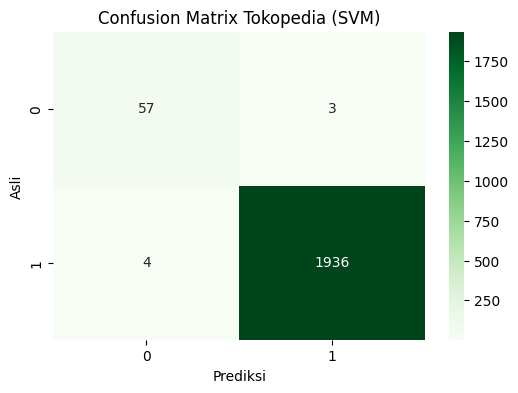

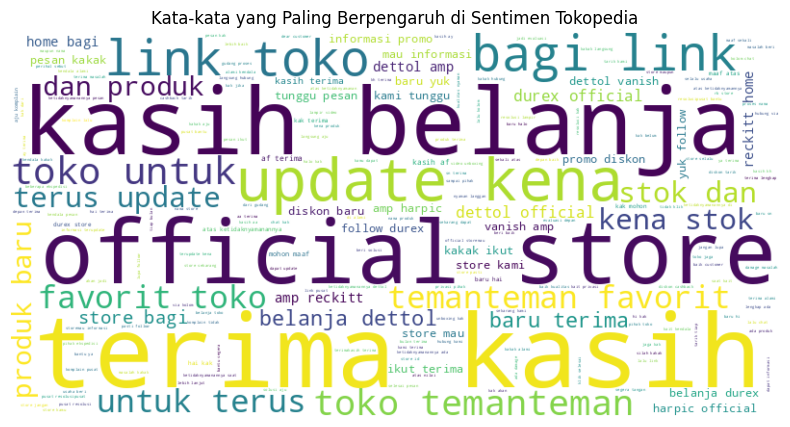

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud

# 1. Tampilkan Classification Report Model SVM
print("Detail Performa Model SVM (TF-IDF):")
print(classification_report(y_test, y_pred_svm))

# 2. Confusion Matrix (Biar laporan ada grafiknya)
cm = confusion_matrix(y_test, y_pred_svm)
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens')
plt.title('Confusion Matrix Tokopedia (SVM)')
plt.xlabel('Prediksi')
plt.ylabel('Asli')
plt.show()

# 3. Word Cloud (Insight Kata-kata Tokopedia)
all_text = ' '.join(df_final['content_cleaned'])
wordcloud = WordCloud(width=800, height=400, background_color='white').generate(all_text)
plt.figure(figsize=(10, 5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title("Kata-kata yang Paling Berpengaruh di Sentimen Tokopedia")
plt.show()

In [ ]:
import pickle
from google.colab import files

# 1. Simpan Model SVM (Model terbaikmu)
with open('model_sentiment_tokopedia.pkl', 'wb') as f:
    pickle.dump(svm_model, f)

# 2. Simpan Vectorizer TF-IDF (Wajib dibawa, karena ini yang mengubah teks jadi angka)
with open('tfidf_vectorizer.pkl', 'wb') as f:
    pickle.dump(tfidf, f)

# 3. Download filenya ke komputer kamu
files.download('model_sentiment_tokopedia.pkl')
files.download('tfidf_vectorizer.pkl')

print("Proses download dimulai... Pastikan browser kamu mengizinkan multiple downloads.")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Proses download dimulai... Pastikan browser kamu mengizinkan multiple downloads.
